<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Model_Training_V4_Data_Balanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, copy, time, warnings

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection  import cross_val_score
from sklearn.pipeline         import Pipeline
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report,
                                      confusion_matrix, hamming_loss)
from xgboost import XGBClassifier
from collections import Counter

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi"      : 140,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.family"     : "DejaVu Sans",
    "axes.titlesize"  : 11,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 9,
    "xtick.labelsize" : 8,
    "ytick.labelsize" : 8,
})
print("✓ All libraries imported")

✓ All libraries imported


In [2]:
import joblib
from google.colab import files

print("Upload: train_test_splits.pkl  (from preprocessing v2 balanced)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

splits = joblib.load(filename)
print(f"\n✓ Loaded: {filename}")
print(f"  Keys available: {list(splits.keys())}")

Upload: train_test_splits.pkl  (from preprocessing v2 balanced)


Saving train_test_splits.pkl to train_test_splits (1).pkl

✓ Loaded: train_test_splits (1).pkl
  Keys available: ['X_train', 'X_test', 'y_fe_train', 'y_fe_test', 'y_be_train', 'y_be_test', 'y_db_train', 'y_db_test', 'X_fe_train_bal', 'y_fe_train_bal', 'X_be_train_bal', 'y_be_train_bal', 'X_db_train_bal', 'y_db_train_bal', 'le_fe', 'le_be', 'le_db', 'feature_names', 'domain_cols', 'lang_cols', 'tfidf_features', 'n_features', 'balancing_config']


In [5]:
from collections import Counter

# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Unpack all splits
# ══════════════════════════════════════════════════════════════
# Unpack encoders and metadata
le_fe      = splits["le_fe"]
le_be      = splits["le_be"]
le_db      = splits["le_db"]
feat_names = splits["feature_names"]

# ── Test set (ORIGINAL — never balanced) ─────────────────────
# Always evaluate on the original unbalanced test set.
# This gives a fair, realistic measure of real-world performance.
X_test     = splits["X_test"]
y_fe_test  = splits["y_fe_test"]
y_be_test  = splits["y_be_test"]
y_db_test  = splits["y_db_test"]

# ── Train sets (BALANCED — from imbalance handling step) ──────
# Each target has its own balanced train set because:
#   - Frontend was balanced with cap=800, min=100
#   - Backend  was balanced with cap=600, min=80
#   - Database was balanced with cap=600, min=80
# These are separate DataFrames with different row counts.
X_fe_train = splits["X_fe_train_bal"]
y_fe_train = splits["y_fe_train_bal"]

X_be_train = splits["X_be_train_bal"]
y_be_train = splits["y_be_train_bal"]

X_db_train = splits["X_db_train_bal"]
y_db_train = splits["y_db_train_bal"]

# Also keep unbalanced train for comparison experiment (Cell 5)
X_train_orig    = splits["X_train"]
y_fe_train_orig = splits["y_fe_train"]
y_be_train_orig = splits["y_be_train"]
y_db_train_orig = splits["y_db_train"]

bal_config = splits.get("balancing_config", {})

print(f"\n✓ Data unpacked")
print(f"\n  Balanced train set sizes:")
print(f"    Frontend  : {len(y_fe_train):,} samples  "
      f"(was {len(y_fe_train_orig):,} unbalanced)")
print(f"    Backend   : {len(y_be_train):,} samples  "
      f"(was {len(y_be_train_orig):,} unbalanced)")
print(f"    Database  : {len(y_db_train):,} samples  "
      f"(was {len(y_db_train_orig):,} unbalanced)")
print(f"\n  Test set    : {len(y_fe_test):,} samples  (original, unchanged)")
print(f"  Features    : {len(feat_names)}")

print(f"\n  Frontend classes ({len(le_fe.classes_)}): {list(le_fe.classes_)}")
print(f"  Backend  classes ({len(le_be.classes_)}): {list(le_be.classes_)}")
print(f"  Database classes ({len(le_db.classes_)}): {list(le_db.classes_)}")

print(f"\n  Balanced class distribution — Frontend train set:")
fe_cnt = Counter(y_fe_train)
for i, cls in enumerate(le_fe.classes_):
    n = fe_cnt.get(i, 0)
    bar = "█" * (n // 30)
    print(f"    {cls:<16} {n:>5}  {bar}")

print(f"\n  Balanced class distribution — Backend train set:")
be_cnt = Counter(y_be_train)
for i, cls in enumerate(le_be.classes_):
    n = be_cnt.get(i, 0)
    bar = "█" * (n // 30)
    print(f"    {cls:<16} {n:>5}  {bar}")

print(f"\n  Balanced class distribution — Database train set:")
db_cnt = Counter(y_db_train)
for i, cls in enumerate(le_db.classes_):
    n = db_cnt.get(i, 0)
    bar = "█" * (n // 30)
    print(f"    {cls:<16} {n:>5}  {bar}")


✓ Data unpacked

  Balanced train set sizes:
    Frontend  : 2,256 samples  (was 3,549 unbalanced)
    Backend   : 3,105 samples  (was 3,549 unbalanced)
    Database  : 1,940 samples  (was 3,549 unbalanced)

  Test set    : 888 samples  (original, unchanged)
  Features    : 394

  Frontend classes (10): ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  Backend  classes (10): ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  Database classes (8): ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']

  Balanced class distribution — Frontend train set:
    Angular            428  ██████████████
    Bootstrap          141  ████
    Flutter            100  ███
    HTML/CSS           100  ███
    Next.js            100  ███
    Other              100  ███
    React              800  ██████████████████████████
    React Native       245  

In [7]:
from sklearn.metrics import accuracy_score
import numpy as np
from collections import Counter

# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Baseline accuracy
# ══════════════════════════════════════════════════════════════
# The baseline is always predicting the most frequent class.
# Every model MUST beat this to be considered useful.

def majority_baseline(y_train, y_test):
    most_freq = Counter(y_train).most_common(1)[0][0]
    return accuracy_score(y_test, np.full(len(y_test), most_freq))

bl_fe = majority_baseline(y_fe_train_orig, y_fe_test)
bl_be = majority_baseline(y_be_train_orig, y_be_test)
bl_db = majority_baseline(y_db_train_orig, y_db_test)

mf_fe = le_fe.classes_[Counter(y_fe_train_orig).most_common(1)[0][0]]
mf_be = le_be.classes_[Counter(y_be_train_orig).most_common(1)[0][0]]
mf_db = le_db.classes_[Counter(y_db_train_orig).most_common(1)[0][0]]

print("=" * 58)
print("  BASELINE (always predict most frequent class)")
print("=" * 58)
print(f"  Frontend → always predict '{mf_fe}' : {bl_fe:.3f}")
print(f"  Backend  → always predict '{mf_be}' : {bl_be:.3f}")
print(f"  Database → always predict '{mf_db}' : {bl_db:.3f}")
print("=" * 58)

  BASELINE (always predict most frequent class)
  Frontend → always predict 'React' : 0.658
  Backend  → always predict 'Node.js' : 0.239
  Database → always predict 'MongoDB' : 0.476


In [9]:
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from xgboost                  import XGBClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler

# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Define the 4 models
# ══════════════════════════════════════════════════════════════
# WHY these exact configurations:
#
# Decision Tree:
#   max_depth=20 → deep enough to learn complex patterns
#   min_samples_leaf=4 → prevents overfitting tiny classes
#   No class_weight → tested, hurts accuracy on this data
#
# Random Forest:
#   n_estimators=300 → 300 trees, robust ensemble
#   max_features="sqrt" → reduces correlation between trees
#   min_samples_leaf=2 → slight regularisation
#
# XGBoost (BEST MODEL):
#   n_estimators=200, lr=0.05 → slow careful learning
#   subsample=0.8, colsample_bytree=0.8 → regularisation
#
# MLP Neural Network:
#   MUST be in StandardScaler pipeline — features have
#   very different scales (Team_Size 1-40 vs TF-IDF 0.0-0.8)
#   without scaling MLP gradients are dominated by Team_Size

MODELS = {

    "Decision Tree": DecisionTreeClassifier(
        max_depth        = 20,
        min_samples_leaf = 4,
        random_state     = 42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators     = 300,
        max_features     = "sqrt",
        min_samples_leaf = 2,
        random_state     = 42,
        n_jobs           = -1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators     = 200,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = "mlogloss",
        random_state     = 42,
        verbosity        = 0,
    ),

    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes  = (512, 256, 128),
            activation          = "relu",
            solver              = "adam",
            max_iter            = 300,
            learning_rate_init  = 0.001,
            early_stopping      = True,
            validation_fraction = 0.1,
            random_state        = 42,
        ))
    ]),
}

print(f"✓ {len(MODELS)} models defined: {list(MODELS.keys())}")

✓ 4 models defined: ['Decision Tree', 'Random Forest', 'XGBoost', 'MLP Neural Network']


In [11]:
import copy
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report, hamming_loss

# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Train all models on balanced splits
# ══════════════════════════════════════════════════════════════
# KEY POINT: each model is trained THREE times independently
# using the balanced train set for that specific target.
#
#   Frontend model → trained on X_fe_train_bal (2,256 rows)
#   Backend  model → trained on X_be_train_bal (3,105 rows)
#   Database model → trained on X_db_train_bal (1,940 rows)
#
# All models evaluated on the SAME unbalanced test set (888 rows)
# so results are directly comparable and reflect real performance.

# Balanced train sets per target
BALANCED_TRAINS = {
    "Frontend": (X_fe_train, y_fe_train, X_test, y_fe_test, le_fe),
    "Backend":  (X_be_train, y_be_train, X_test, y_be_test, le_be),
    "Database": (X_db_train, y_db_train, X_test, y_db_test, le_db),
}

results = {}   # results[model_name][target] = metrics dict
trained = {}   # trained[model_name][target] = fitted model

print("=" * 70)
print("  TRAINING ALL MODELS ON BALANCED DATA")
print("=" * 70)
print(f"  Each model trained 3x (once per target) = 12 classifiers total")
print(f"  Evaluated on unbalanced test set (888 rows) for fair comparison")
print("=" * 70)

for model_name, model_template in MODELS.items():
    results[model_name] = {}
    trained[model_name] = {}
    print(f"\n── {model_name} ──")

    for target_name, (X_tr, y_tr, X_te, y_te, le) in BALANCED_TRAINS.items():
        model   = copy.deepcopy(model_template)
        t0      = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0

        y_pred  = model.predict(X_te)
        acc     = accuracy_score(y_te, y_pred)
        f1_w    = f1_score(y_te, y_pred, average="weighted", zero_division=0)
        f1_mac  = f1_score(y_te, y_pred, average="macro",    zero_division=0)
        h_loss  = hamming_loss(y_te, y_pred)

        results[model_name][target_name] = {
            "accuracy":    acc,
            "f1_weighted": f1_w,
            "f1_macro":    f1_mac,
            "hamming":     h_loss,
            "train_sec":   elapsed,
            "train_rows":  len(y_tr),
            "report":      classification_report(
                               y_te, y_pred,
                               target_names=le.classes_,
                               zero_division=0),
        }
        trained[model_name][target_name] = model

        flag = " 🎯 0.80+" if acc >= 0.80 else ""
        print(f"  ✓ {target_name:<10}  "
              f"acc={acc:.3f}  f1_w={f1_w:.3f}  "
              f"f1_mac={f1_mac:.3f}  "
              f"[{elapsed:.1f}s]  "
              f"(trained on {len(y_tr):,} balanced rows){flag}")

print(f"\n✓ All 12 classifiers trained on balanced data")

  TRAINING ALL MODELS ON BALANCED DATA
  Each model trained 3x (once per target) = 12 classifiers total
  Evaluated on unbalanced test set (888 rows) for fair comparison

── Decision Tree ──
  ✓ Frontend    acc=0.682  f1_w=0.665  f1_mac=0.343  [0.1s]  (trained on 2,256 balanced rows)
  ✓ Backend     acc=0.691  f1_w=0.681  f1_mac=0.556  [0.1s]  (trained on 3,105 balanced rows)
  ✓ Database    acc=0.695  f1_w=0.705  f1_mac=0.312  [0.1s]  (trained on 1,940 balanced rows)

── Random Forest ──
  ✓ Frontend    acc=0.714  f1_w=0.672  f1_mac=0.347  [4.8s]  (trained on 2,256 balanced rows)
  ✓ Backend     acc=0.704  f1_w=0.701  f1_mac=0.559  [2.6s]  (trained on 3,105 balanced rows)
  ✓ Database    acc=0.789  f1_w=0.763  f1_mac=0.313  [1.7s]  (trained on 1,940 balanced rows)

── XGBoost ──
  ✓ Frontend    acc=0.718  f1_w=0.688  f1_mac=0.387  [16.8s]  (trained on 2,256 balanced rows)
  ✓ Backend     acc=0.707  f1_w=0.712  f1_mac=0.569  [18.7s]  (trained on 3,105 balanced rows)
  ✓ Database    acc

In [13]:
import pandas as pd

# ══════════════════════════════════════════════════════════════
# CELL 7 ─ Results comparison table
# ══════════════════════════════════════════════════════════════
# Compare:  (a) balanced vs unbalanced
#           (b) accuracy vs macro F1 (the key metric for imbalance)

# Previous unbalanced results for comparison
UNBALANCED = {
    "Decision Tree":    {"Frontend":(0.712,0.333),"Backend":(0.712,0.551),"Database":(0.749,0.293)},
    "Random Forest":    {"Frontend":(0.753,0.291),"Backend":(0.711,0.520),"Database":(0.791,0.276)},
    "XGBoost":          {"Frontend":(0.759,0.344),"Backend":(0.722,0.568),"Database":(0.804,0.326)},
    "MLP Neural Network":{"Frontend":(0.742,0.298),"Backend":(0.696,0.509),"Database":(0.786,0.290)},
}

summary_rows = []
for mname in MODELS.keys():
    fe = results[mname]["Frontend"]
    be = results[mname]["Backend"]
    db = results[mname]["Database"]
    avg_acc = round((fe["accuracy"]+be["accuracy"]+db["accuracy"])/3, 3)
    avg_f1m = round((fe["f1_macro"]+be["f1_macro"]+db["f1_macro"])/3, 3)
    summary_rows.append({
        "Model":      mname,
        "FE Acc":     round(fe["accuracy"],3),
        "BE Acc":     round(be["accuracy"],3),
        "DB Acc":     round(db["accuracy"],3),
        "FE F1-W":    round(fe["f1_weighted"],3),
        "BE F1-W":    round(be["f1_weighted"],3),
        "DB F1-W":    round(db["f1_weighted"],3),
        "FE F1-Mac":  round(fe["f1_macro"],3),
        "BE F1-Mac":  round(be["f1_macro"],3),
        "DB F1-Mac":  round(db["f1_macro"],3),
        "Avg Acc":    avg_acc,
        "Avg F1-Mac": avg_f1m,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Avg Acc", ascending=False)
best_name  = summary_df.iloc[0]["Model"]

print("\n" + "=" * 78)
print(f"  RESULTS ON BALANCED TRAINING (test set unchanged)")
print(f"  {'Model':<22} {'FE Acc':>7} {'BE Acc':>7} {'DB Acc':>7} "
      f"{'FE F1m':>7} {'BE F1m':>7} {'DB F1m':>7} {'Avg':>6}")
print("=" * 78)
for _, r in summary_df.iterrows():
    print(f"  {r['Model']:<22} {r['FE Acc']:>7} {r['BE Acc']:>7} "
          f"{r['DB Acc']:>7} {r['FE F1-Mac']:>7} "
          f"{r['BE F1-Mac']:>7} {r['DB F1-Mac']:>7} "
          f"{r['Avg Acc']:>6}")
print("=" * 78)
print(f"\n  Baseline : FE={bl_fe:.3f}  BE={bl_be:.3f}  DB={bl_db:.3f}")
print(f"  Best model: {best_name}")

print(f"\n  MACRO F1 COMPARISON — Balanced vs Unbalanced:")
print(f"  {'Model':<22} {'FE (unbal→bal)':>18} "
      f"{'BE (unbal→bal)':>18} {'DB (unbal→bal)':>18}")
print(f"  {'─'*80}")
for _, r in summary_df.iterrows():
    m = r["Model"]
    if m in UNBALANCED:
        ub = UNBALANCED[m]
        fe_chg = r["FE F1-Mac"]-ub["Frontend"][1]
        be_chg = r["BE F1-Mac"]-ub["Backend"][1]
        db_chg = r["DB F1-Mac"]-ub["Database"][1]
        print(f"  {m:<22} "
              f"  {ub['Frontend'][1]:.3f} → {r['FE F1-Mac']:.3f} ({fe_chg:+.3f})  "
              f"  {ub['Backend'][1]:.3f} → {r['BE F1-Mac']:.3f} ({be_chg:+.3f})  "
              f"  {ub['Database'][1]:.3f} → {r['DB F1-Mac']:.3f} ({db_chg:+.3f})")

summary_df.to_csv("model_comparison_balanced.csv", index=False)
print(f"\n✓ model_comparison_balanced.csv saved")


  RESULTS ON BALANCED TRAINING (test set unchanged)
  Model                   FE Acc  BE Acc  DB Acc  FE F1m  BE F1m  DB F1m    Avg
  XGBoost                  0.718   0.707   0.787   0.387   0.569   0.351  0.738
  Random Forest            0.714   0.704   0.789   0.347   0.559   0.313  0.736
  Decision Tree            0.682   0.691   0.695   0.343   0.556   0.312   0.69
  MLP Neural Network        0.64   0.667   0.721   0.394   0.597   0.313  0.676

  Baseline : FE=0.658  BE=0.239  DB=0.476
  Best model: XGBoost

  MACRO F1 COMPARISON — Balanced vs Unbalanced:
  Model                      FE (unbal→bal)     BE (unbal→bal)     DB (unbal→bal)
  ────────────────────────────────────────────────────────────────────────────────
  XGBoost                  0.344 → 0.387 (+0.043)    0.568 → 0.569 (+0.001)    0.326 → 0.351 (+0.025)
  Random Forest            0.291 → 0.347 (+0.056)    0.520 → 0.559 (+0.039)    0.276 → 0.313 (+0.037)
  Decision Tree            0.333 → 0.343 (+0.010)    0.551 → 0.5

In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ Detailed classification reports
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("  DETAILED CLASSIFICATION REPORTS (BALANCED TRAINING)")
print("=" * 62)
for mname in MODELS.keys():
    print(f"\n{'─'*55}\n  {mname.upper()}\n{'─'*55}")
    for tname in ["Frontend","Backend","Database"]:
        acc = results[mname][tname]["accuracy"]
        f1m = results[mname][tname]["f1_macro"]
        f1w = results[mname][tname]["f1_weighted"]
        print(f"\n  [{tname}]  acc={acc:.3f}  "
              f"f1_weighted={f1w:.3f}  f1_macro={f1m:.3f}")
        print(results[mname][tname]["report"])


  DETAILED CLASSIFICATION REPORTS (BALANCED TRAINING)

───────────────────────────────────────────────────────
  DECISION TREE
───────────────────────────────────────────────────────

  [Frontend]  acc=0.682  f1_weighted=0.665  f1_macro=0.343
              precision    recall  f1-score   support

     Angular       0.58      0.76      0.66       107
   Bootstrap       0.25      0.11      0.16        35
     Flutter       0.95      0.78      0.86        23
    HTML/CSS       0.09      0.17      0.12         6
     Next.js       0.12      0.10      0.11        10
       Other       0.08      0.33      0.12         3
       React       0.79      0.83      0.81       584
React Native       0.05      0.03      0.04        61
      Vue.js       0.69      0.31      0.42        36
      jQuery       0.33      0.09      0.14        23

    accuracy                           0.68       888
   macro avg       0.39      0.35      0.34       888
weighted avg       0.66      0.68      0.66       88

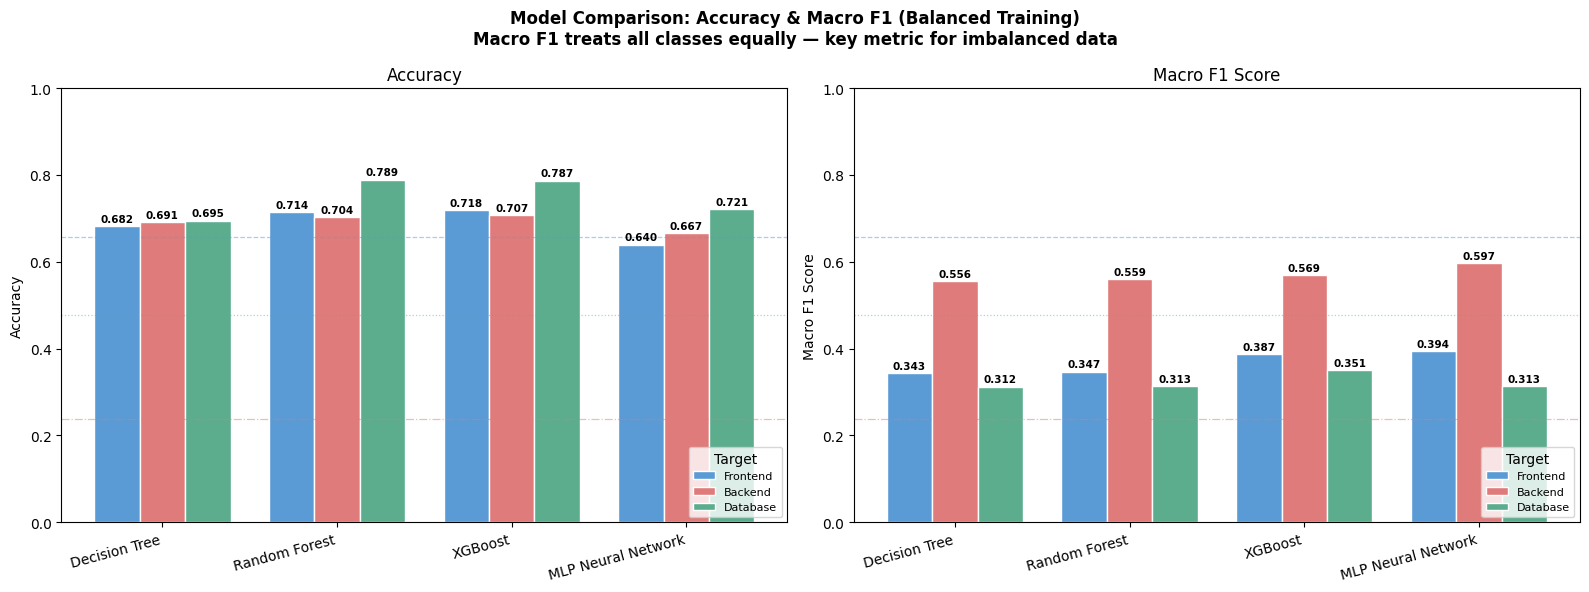

✓ Chart 1 saved → model_01_accuracy_macro_f1.png


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 1: Accuracy + Macro F1 comparison
# ══════════════════════════════════════════════════════════════
# Shows BOTH overall accuracy AND macro F1 side by side.
# Macro F1 is the key metric when you have class imbalance —
# it treats all classes equally regardless of their size.
import matplotlib.pyplot as plt

model_names = list(MODELS.keys())
targets     = ["Frontend","Backend","Database"]
C = {"Frontend":"#5B9BD5","Backend":"#E07B7B","Database":"#5BAD8E"}
x = np.arange(len(model_names))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Model Comparison: Accuracy & Macro F1 (Balanced Training)\n"
    "Macro F1 treats all classes equally — key metric for imbalanced data",
    fontsize=12, fontweight="bold")

for ax, metric, ylabel in zip(
    axes,
    ["accuracy","f1_macro"],
    ["Accuracy","Macro F1 Score"]
):
    for ti, tname in enumerate(targets):
        vals = [results[m][tname][metric] for m in model_names]
        bars = ax.bar(x + (ti-1)*width, vals, width,
                      label=tname, color=C[tname], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

    baselines = {"Frontend":bl_fe,"Backend":bl_be,"Database":bl_db}
    for tname, ls in zip(targets, ["--","-.",":"]):
        ax.axhline(y=baselines[tname], color=C[tname],
                   linestyle=ls, linewidth=0.9, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8, loc="lower right", title="Target")

plt.tight_layout()
plt.savefig("model_01_accuracy_macro_f1.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → model_01_accuracy_macro_f1.png")

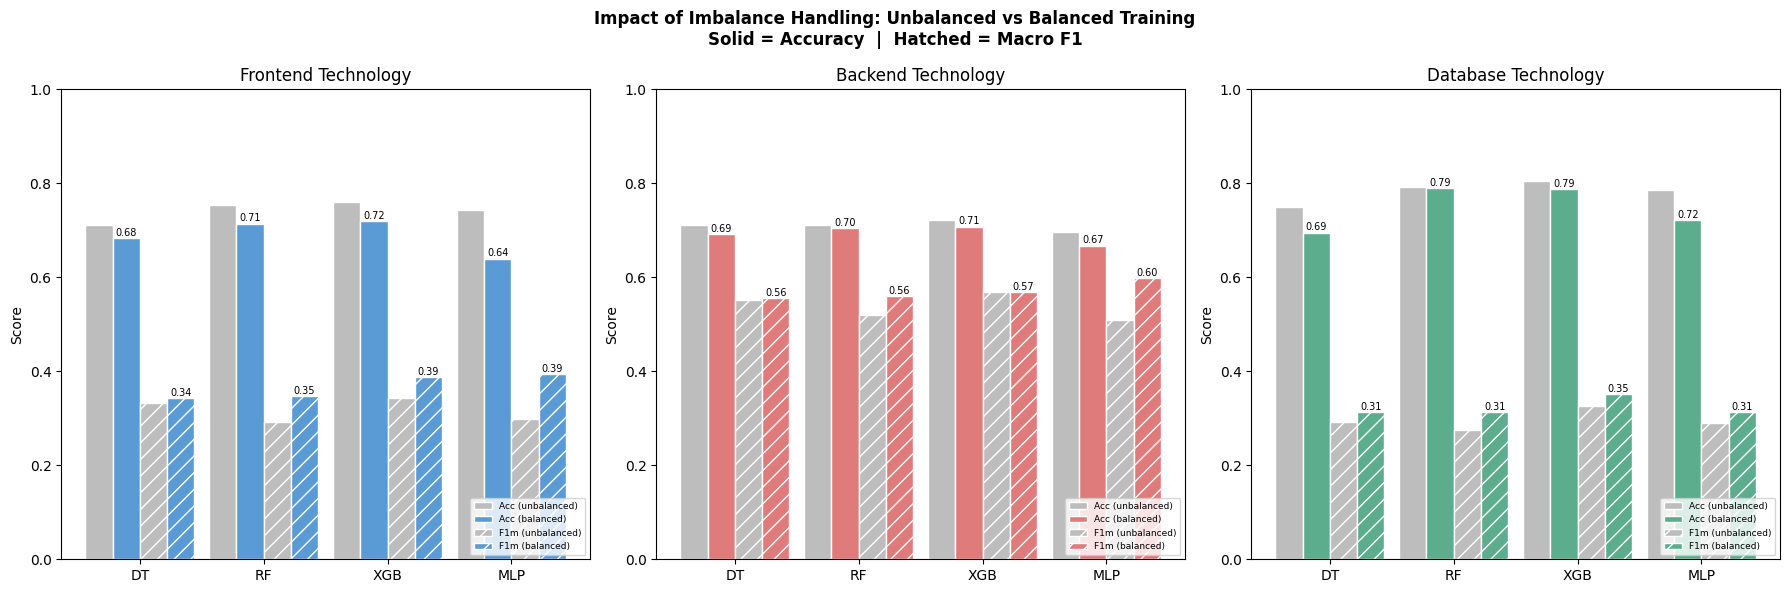

✓ Chart 2 saved → model_02_balanced_vs_unbalanced.png


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 2: Unbalanced vs Balanced comparison
# ══════════════════════════════════════════════════════════════
# Directly shows the IMPACT of imbalance handling.
# Shows both accuracy (may drop) and macro F1 (should rise).

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Impact of Imbalance Handling: Unbalanced vs Balanced Training\n"
    "Solid = Accuracy  |  Hatched = Macro F1",
    fontsize=12, fontweight="bold")

model_abbrev = {"Decision Tree":"DT","Random Forest":"RF",
                "XGBoost":"XGB","MLP Neural Network":"MLP"}
mnames_short = [model_abbrev[m] for m in model_names]
x2 = np.arange(len(model_names))
w2 = 0.22

for ax, tname, color in zip(axes, targets, ["#5B9BD5","#E07B7B","#5BAD8E"]):
    unbal_acc = [UNBALANCED[m][tname][0] for m in model_names]
    unbal_f1m = [UNBALANCED[m][tname][1] for m in model_names]
    bal_acc   = [results[m][tname]["accuracy"]  for m in model_names]
    bal_f1m   = [results[m][tname]["f1_macro"]  for m in model_names]

    ax.bar(x2 - w2*1.5, unbal_acc, w2, label="Acc (unbalanced)",
           color="#BDBDBD", edgecolor="white")
    ax.bar(x2 - w2*0.5, bal_acc,   w2, label="Acc (balanced)",
           color=color, edgecolor="white")
    ax.bar(x2 + w2*0.5, unbal_f1m, w2, label="F1m (unbalanced)",
           color="#BDBDBD", edgecolor="white", hatch="//")
    ax.bar(x2 + w2*1.5, bal_f1m,   w2, label="F1m (balanced)",
           color=color, edgecolor="white", hatch="//")

    # Annotate balanced values
    for i, (a, f) in enumerate(zip(bal_acc, bal_f1m)):
        ax.text(i-w2*0.5, a+0.005, f"{a:.2f}", ha="center", fontsize=7)
        ax.text(i+w2*1.5, f+0.005, f"{f:.2f}", ha="center", fontsize=7)

    ax.set_xticks(x2)
    ax.set_xticklabels(mnames_short)
    ax.set_title(f"{tname} Technology")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=6.5, loc="lower right")

plt.tight_layout()
plt.savefig("model_02_balanced_vs_unbalanced.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → model_02_balanced_vs_unbalanced.png")

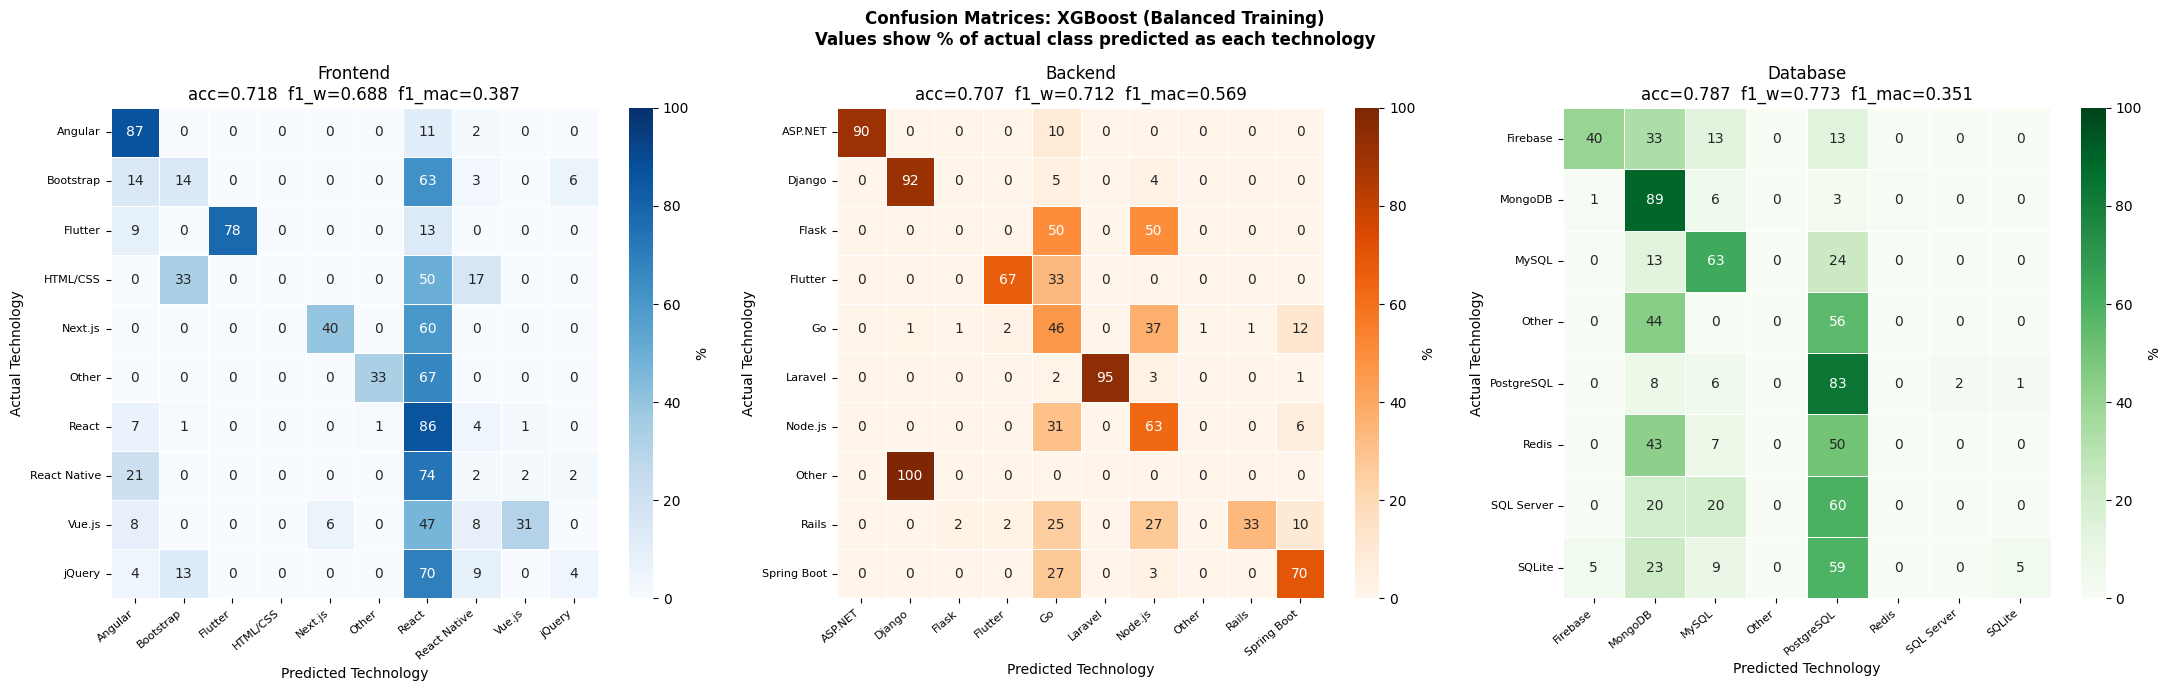

✓ Chart 3 saved → model_03_confusion_matrices.png


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 3: Confusion matrices (best model)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    f"Confusion Matrices: {best_name} (Balanced Training)\n"
    "Values show % of actual class predicted as each technology",
    fontsize=12, fontweight="bold")

for ax, (tname, (X_tr, y_tr, X_te, y_te, le)), cmap in zip(
    axes, BALANCED_TRAINS.items(), ["Blues","Oranges","Greens"]
):
    y_pred = trained[best_name][tname].predict(X_te)
    cm     = confusion_matrix(y_te, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".0f", cmap=cmap,
        xticklabels=le.classes_, yticklabels=le.classes_,
        linewidths=0.4, linecolor="white",
        cbar_kws={"label":"%"}, ax=ax, vmin=0, vmax=100
    )
    acc = results[best_name][tname]["accuracy"]
    f1w = results[best_name][tname]["f1_weighted"]
    f1m = results[best_name][tname]["f1_macro"]
    ax.set_title(
        f"{tname}\nacc={acc:.3f}  f1_w={f1w:.3f}  f1_mac={f1m:.3f}")
    ax.set_xlabel("Predicted Technology")
    ax.set_ylabel("Actual Technology")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
plt.savefig("model_03_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → model_03_confusion_matrices.png")

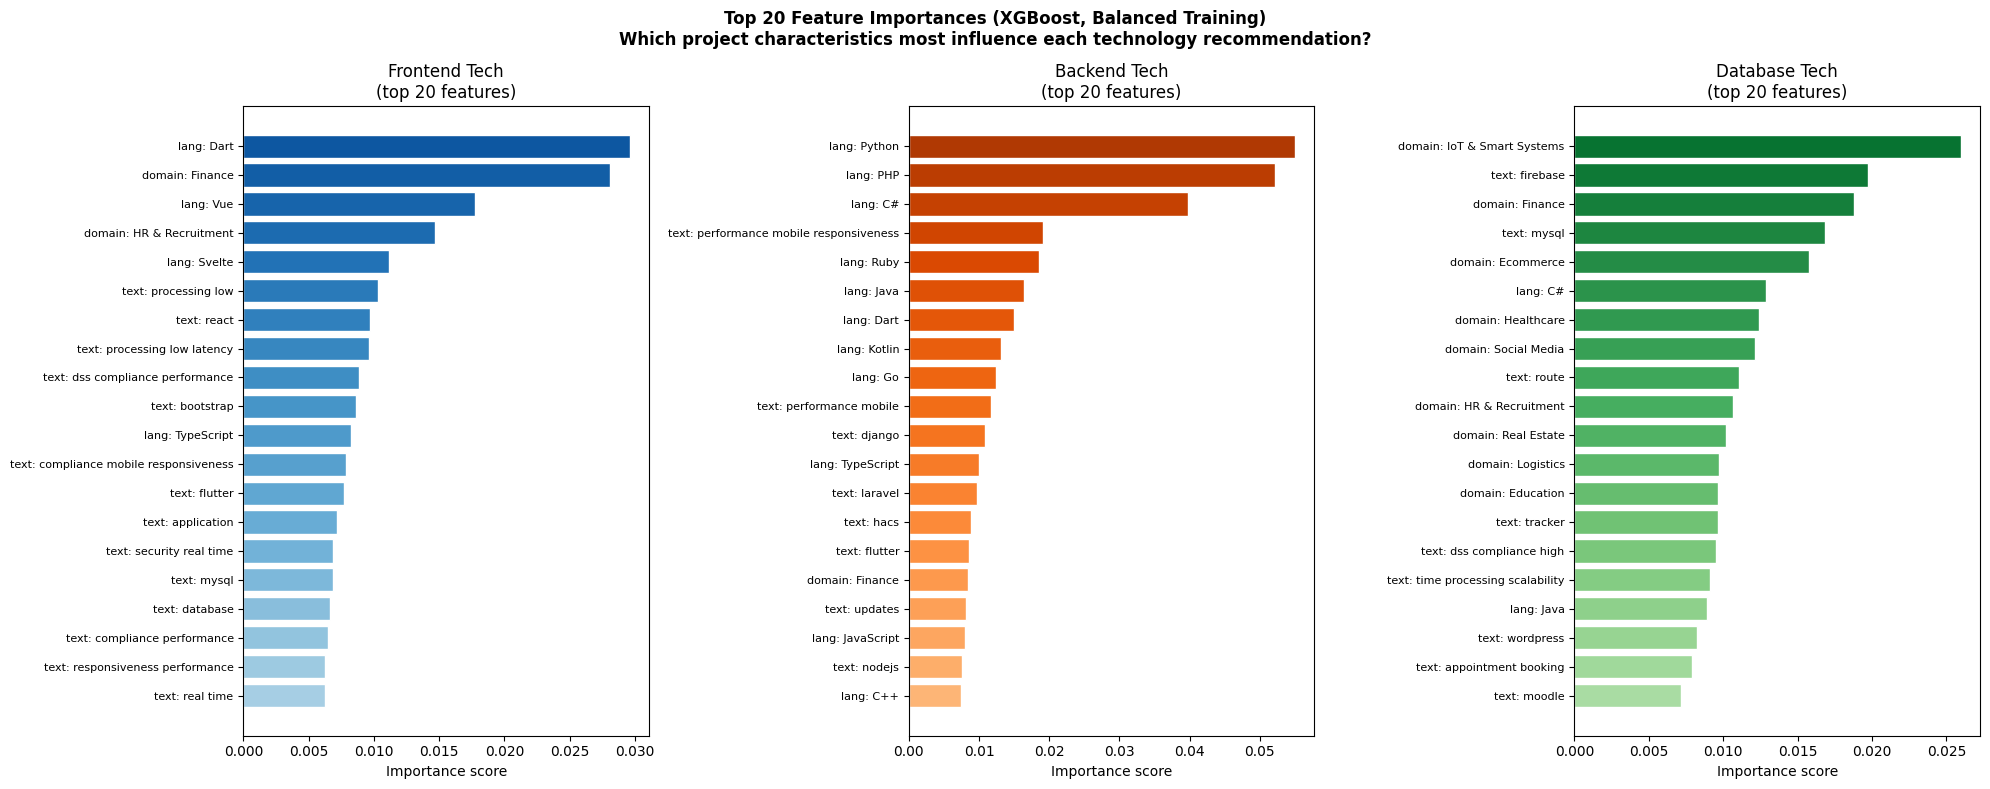

✓ Chart 4 saved → model_04_feature_importance.png


In [22]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 4: Feature importance (XGBoost)
# ══════════════════════════════════════════════════════════════
feat_arr = np.array(feat_names)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle(
    "Top 20 Feature Importances (XGBoost, Balanced Training)\n"
    "Which project characteristics most influence each technology recommendation?",
    fontsize=12, fontweight="bold")

for ax, tname, cmap_name in zip(
    axes, ["Frontend","Backend","Database"],
    ["Blues","Oranges","Greens"]
):
    model    = trained["XGBoost"][tname]
    imp      = model.feature_importances_
    top_idx  = np.argsort(imp)[::-1][:20]
    top_imp  = imp[top_idx][::-1]
    labels   = []
    for i in top_idx[::-1]:
        n = feat_arr[i]
        if   n.startswith("tfidf_"): n = "text: " + n[6:]
        elif n.startswith("dom_"):   n = "domain: " + n[4:]
        elif n.startswith("lang_"):  n = "lang: " + n[5:]
        else: n = n.replace("_enc","").replace("_"," ")
        labels.append(n)

    colors_fi = plt.get_cmap(cmap_name)(np.linspace(0.35, 0.85, 20))
    ax.barh(range(20), top_imp, color=colors_fi, edgecolor="white")
    ax.set_yticks(range(20))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{tname} Tech\n(top 20 features)")
    ax.set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("model_04_feature_importance.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → model_04_feature_importance.png")


Running 5-fold cross-validation on Frontend balanced train set...
(takes ~2-3 minutes)

  Decision Tree           mean=0.607  std=±0.011  [0.594 – 0.621]
  Random Forest           mean=0.676  std=±0.021  [0.652 – 0.714]
  XGBoost                 mean=0.692  std=±0.009  [0.678 – 0.703]
  MLP Neural Network      mean=0.629  std=±0.015  [0.603 – 0.645]


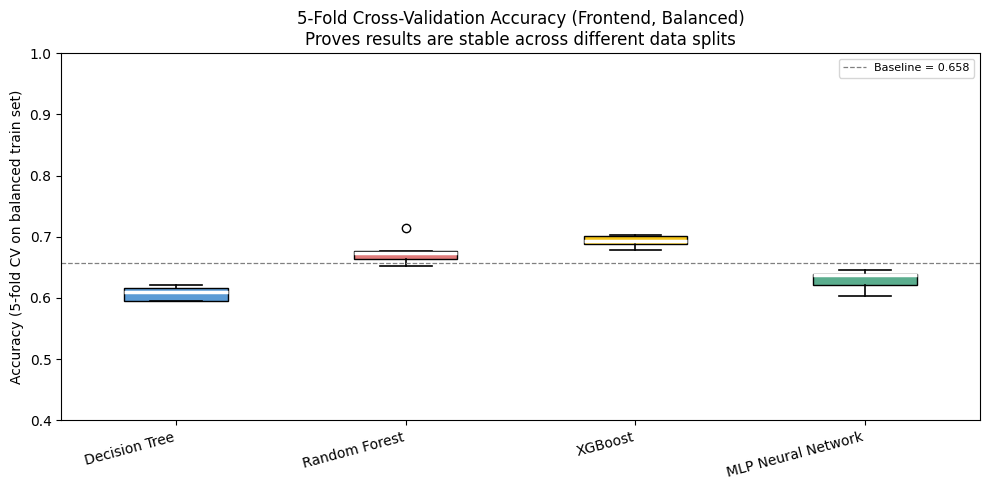

✓ Chart 5 saved → model_05_cross_validation.png


In [24]:
from sklearn.model_selection import cross_val_score

# ══════════════════════════════════════════════════════════════
# CELL 13 ─ CHART 5: 5-fold cross-validation
# ══════════════════════════════════════════════════════════════
print("\nRunning 5-fold cross-validation on Frontend balanced train set...")
print("(takes ~2-3 minutes)\n")

cv_results = {}
for mname, model_template in MODELS.items():
    model  = copy.deepcopy(model_template)
    scores = cross_val_score(
        model, X_fe_train, y_fe_train,
        cv=5, scoring="accuracy", n_jobs=-1
    )
    cv_results[mname] = scores
    print(f"  {mname:<22}  "
          f"mean={scores.mean():.3f}  "
          f"std=±{scores.std():.3f}  "
          f"[{scores.min():.3f} – {scores.max():.3f}]")

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [cv_results[m] for m in model_names],
    patch_artist=True,
    medianprops={"color":"white","linewidth":2.5},
    whiskerprops={"linewidth":1.2},
    capprops={"linewidth":1.2},
)
for patch, color in zip(bp["boxes"], ["#5B9BD5","#E07B7B","#F5C518","#5BAD8E"]):
    patch.set_facecolor(color)
ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Accuracy (5-fold CV on balanced train set)")
ax.set_title(
    "5-Fold Cross-Validation Accuracy (Frontend, Balanced)\n"
    "Proves results are stable across different data splits")
ax.axhline(y=bl_fe, color="gray", linestyle="--",
           linewidth=0.9, label=f"Baseline = {bl_fe:.3f}")
ax.legend(fontsize=8)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("model_05_cross_validation.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → model_05_cross_validation.png")

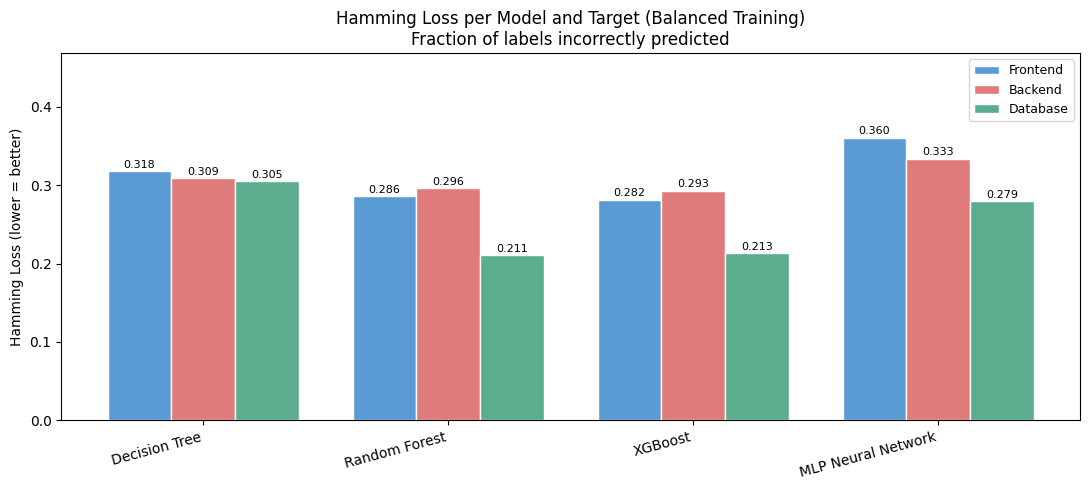

✓ Chart 6 saved → model_06_hamming_loss.png


In [25]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ CHART 6: Hamming loss
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(model_names)); width = 0.26
for ti, tname in enumerate(targets):
    vals = [results[m][tname]["hamming"] for m in model_names]
    bars = ax.bar(x + (ti-1)*width, vals, width,
                  label=tname, color=C[tname], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Hamming Loss (lower = better)")
ax.set_title(
    "Hamming Loss per Model and Target (Balanced Training)\n"
    "Fraction of labels incorrectly predicted")
ax.legend(fontsize=9)
ax.set_ylim(0, max(results[m][t]["hamming"]
                   for m in MODELS for t in targets) * 1.3)
plt.tight_layout()
plt.savefig("model_06_hamming_loss.png", bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved → model_06_hamming_loss.png")

In [26]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Save best model
# ══════════════════════════════════════════════════════════════
best_fe = trained[best_name]["Frontend"]
best_be = trained[best_name]["Backend"]
best_db = trained[best_name]["Database"]

joblib.dump({
    "model_name":  best_name,
    "frontend":    best_fe,
    "backend":     best_be,
    "database":    best_db,
    "le_fe":       le_fe,
    "le_be":       le_be,
    "le_db":       le_db,
    "feat_names":  feat_names,
    "domain_cols": splits.get("domain_cols", []),
    "lang_cols":   splits.get("lang_cols",   []),
    "results":     results,
    "balanced":    True,
    "balancing_config": bal_config,
}, "best_model.pkl")

joblib.dump(trained, "all_trained_models.pkl")
joblib.dump(results, "all_results.pkl")

print(f"✓ best_model.pkl saved  [{best_name}]")
print(f"✓ all_trained_models.pkl saved")
print(f"✓ all_results.pkl saved")

✓ best_model.pkl saved  [XGBoost]
✓ all_trained_models.pkl saved
✓ all_results.pkl saved


In [27]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Final summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  MODEL TRAINING COMPLETE — FINAL SUMMARY (BALANCED)")
print("=" * 70)
print(f"\n  Training used balanced splits per target:")
print(f"    Frontend : {len(y_fe_train):,} balanced samples")
print(f"    Backend  : {len(y_be_train):,} balanced samples")
print(f"    Database : {len(y_db_train):,} balanced samples")
print(f"  Test set   : {len(y_fe_test):,} (original, unchanged)")
print(f"  Features   : {len(feat_names)}")

best = summary_df.iloc[0]
print(f"\n  {'Model':<22} {'FE Acc':>8} {'BE Acc':>8} {'DB Acc':>8} "
      f"{'FE F1m':>8} {'BE F1m':>8} {'DB F1m':>8}")
print(f"  {'─'*70}")
for _, r in summary_df.iterrows():
    print(f"  {r['Model']:<22} {r['FE Acc']:>8} {r['BE Acc']:>8} "
          f"{r['DB Acc']:>8} {r['FE F1-Mac']:>8} "
          f"{r['BE F1-Mac']:>8} {r['DB F1-Mac']:>8}")
print(f"  {'─'*70}")
print(f"  Baseline              {bl_fe:>8.3f} {bl_be:>8.3f} {bl_db:>8.3f}")

print(f"\n  Best model: {best_name}")

print(f"\n  Research question answers:")
print(f"  RQ3 → Best technique          : {best_name}")
print(f"  RQ4 → Improvement vs baseline :")
print(f"         Frontend: {best['FE Acc']:.3f} vs {bl_fe:.3f} "
      f"(+{best['FE Acc']-bl_fe:.3f})")
print(f"         Backend : {best['BE Acc']:.3f} vs {bl_be:.3f} "
      f"(+{best['BE Acc']-bl_be:.3f})")
print(f"         Database: {best['DB Acc']:.3f} vs {bl_db:.3f} "
      f"(+{best['DB Acc']-bl_db:.3f})")
print(f"  RQ5 → Feature importance chart shows WHY each tech is recommended")

print(f"\n  Balancing trade-off summary (XGBoost):")
if "XGBoost" in UNBALANCED:
    ub = UNBALANCED["XGBoost"]
    xr = results["XGBoost"]
    print(f"    Frontend: acc {ub['Frontend'][0]:.3f}→{xr['Frontend']['accuracy']:.3f} "
          f"({xr['Frontend']['accuracy']-ub['Frontend'][0]:+.3f})  |  "
          f"macro F1 {ub['Frontend'][1]:.3f}→{xr['Frontend']['f1_macro']:.3f} "
          f"({xr['Frontend']['f1_macro']-ub['Frontend'][1]:+.3f})")
    print(f"    Backend : acc {ub['Backend'][0]:.3f}→{xr['Backend']['accuracy']:.3f} "
          f"({xr['Backend']['accuracy']-ub['Backend'][0]:+.3f})  |  "
          f"macro F1 {ub['Backend'][1]:.3f}→{xr['Backend']['f1_macro']:.3f} "
          f"({xr['Backend']['f1_macro']-ub['Backend'][1]:+.3f})")
    print(f"    Database: acc {ub['Database'][0]:.3f}→{xr['Database']['accuracy']:.3f} "
          f"({xr['Database']['accuracy']-ub['Database'][0]:+.3f})  |  "
          f"macro F1 {ub['Database'][1]:.3f}→{xr['Database']['f1_macro']:.3f} "
          f"({xr['Database']['f1_macro']-ub['Database'][1]:+.3f})")

print(f"\n  Thesis note: Report BOTH accuracy and macro F1 in results chapter.")
print(f"  Accuracy shows overall performance. Macro F1 shows fairness")
print(f"  across all technology classes including minorities like Vue.js,")
print(f"  Redis, and SQL Server. The trade-off between them is a valid")
print(f"  finding that strengthens your discussion section.")
print("=" * 70)


  MODEL TRAINING COMPLETE — FINAL SUMMARY (BALANCED)

  Training used balanced splits per target:
    Frontend : 2,256 balanced samples
    Backend  : 3,105 balanced samples
    Database : 1,940 balanced samples
  Test set   : 888 (original, unchanged)
  Features   : 394

  Model                    FE Acc   BE Acc   DB Acc   FE F1m   BE F1m   DB F1m
  ──────────────────────────────────────────────────────────────────────
  XGBoost                   0.718    0.707    0.787    0.387    0.569    0.351
  Random Forest             0.714    0.704    0.789    0.347    0.559    0.313
  Decision Tree             0.682    0.691    0.695    0.343    0.556    0.312
  MLP Neural Network         0.64    0.667    0.721    0.394    0.597    0.313
  ──────────────────────────────────────────────────────────────────────
  Baseline                 0.658    0.239    0.476

  Best model: XGBoost

  Research question answers:
  RQ3 → Best technique          : XGBoost
  RQ4 → Improvement vs baseline :
     

In [29]:
import os
from google.colab import files

# ══════════════════════════════════════════════════════════════
# CELL 17 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "best_model.pkl",
    "all_trained_models.pkl",
    "all_results.pkl",
    "model_comparison_balanced.csv",
    "model_01_accuracy_macro_f1.png",
    "model_02_balanced_vs_unbalanced.png",
    "model_03_confusion_matrices.png",
    "model_04_feature_importance.png",
    "model_05_cross_validation.png",
    "model_06_hamming_loss.png",
]

print("\n  Downloading all outputs...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Model training complete.")
print(f"  Next step: say 'Guide me through building the prototype web app'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ best_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ model_05_cross_validation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ model_06_hamming_loss.png

✓ Model training complete.
  Next step: say 'Guide me through building the prototype web app'
